In [225]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [226]:
df = pd.read_excel("heart_disease.xlsx",sheet_name=1)  #sheet_name=1 giives the 2nd sheet from xlsx file
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [227]:
#Shape of DataSet
df.shape

(908, 13)

In [228]:
#Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [229]:
df['num'] = df.num.map({0: 0, 1: 1, 2: 1, 3: 1, 4: 1})  #Convert to 0 and 1  -> 0-no heart disease , 1-heart disease

In [230]:
#Summary Statistics
df.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,846.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.891253,0.560573
std,9.158031,20.401608,112.097949,26.804929,1.093875,0.496591
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,1.000000


In [231]:
#Checking Missing Values
df.isnull().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64

In [232]:
# Handling Missing Values 
df['oldpeak'] = df['oldpeak'].fillna(df['oldpeak'].median())

In [233]:
#Verify
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
num         0
dtype: int64

In [234]:
#Duplicate records
df.duplicated().sum()

np.int64(1)

In [235]:
# drop duplicate
df.drop_duplicates(inplace=True)

In [236]:
df.duplicated().sum()

np.int64(0)

# Task 2: Exploratory Data Analysis (EDA)

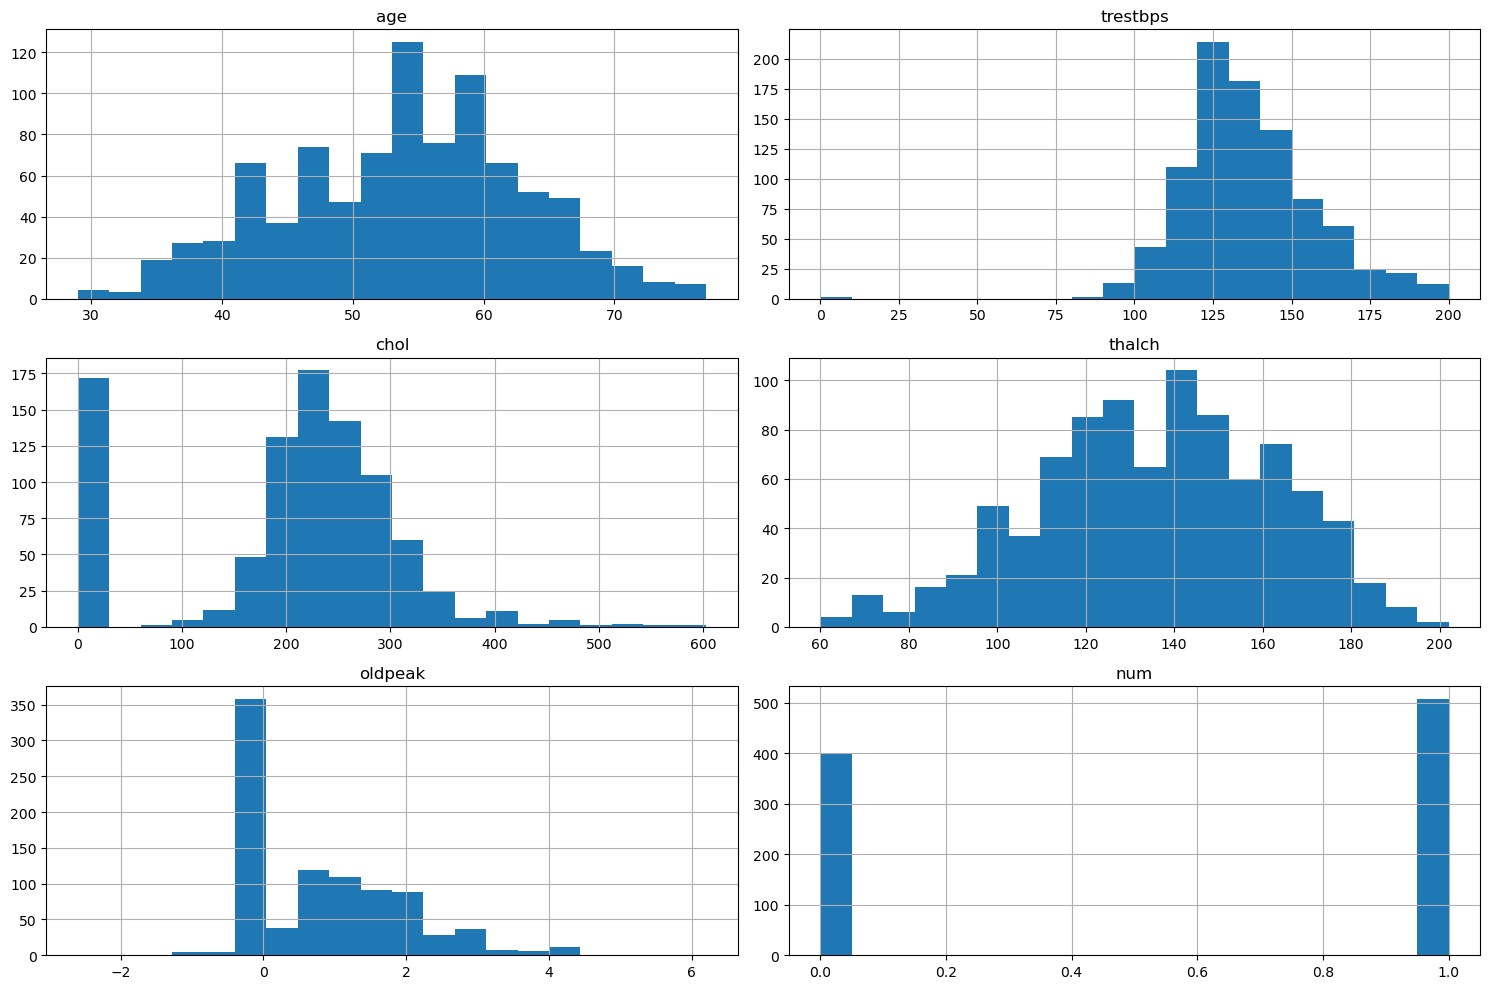

In [237]:
#Histogram
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols].hist(figsize=(15,10), bins=20)
plt.tight_layout()
plt.show()

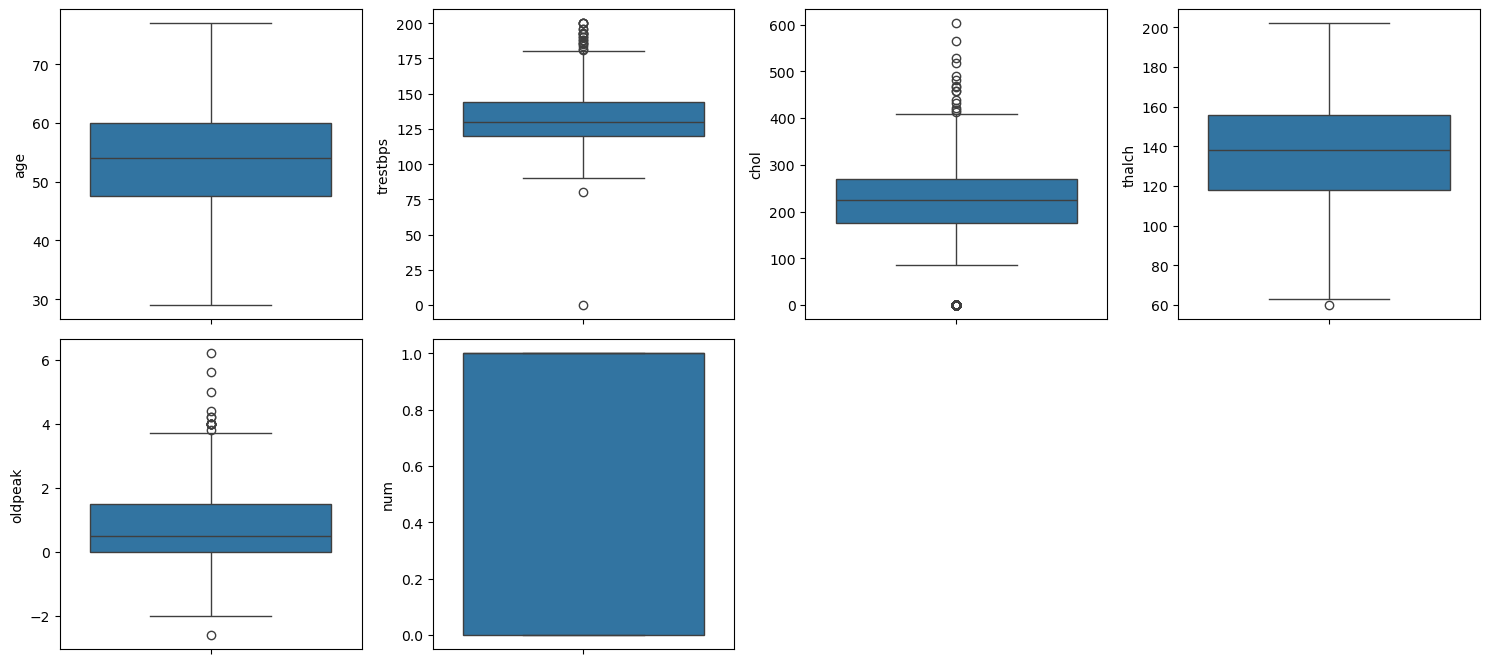

In [238]:
#BOX Plots
plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols,1):
    plt.subplot(3,4,i)
    sns.boxplot(y=df[col])
plt.tight_layout()
plt.show()

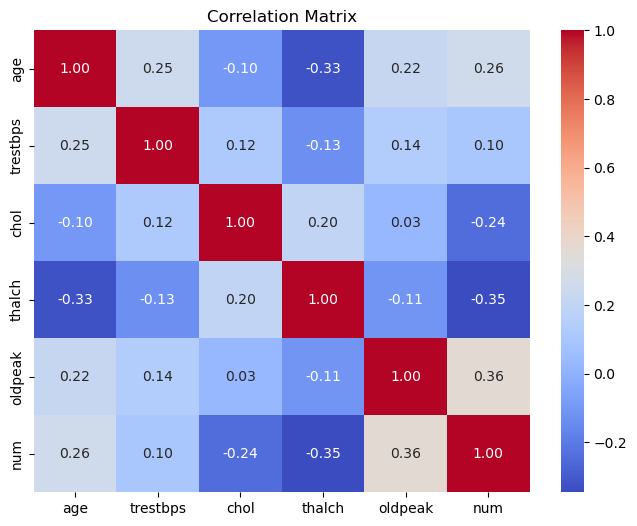

In [239]:
# Correlation Matrix
plt.figure(figsize=(8,6))

sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

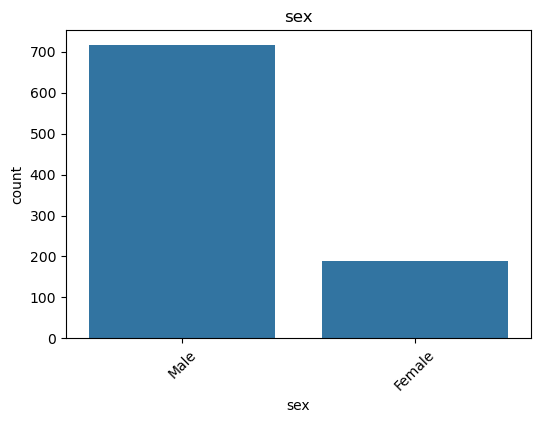

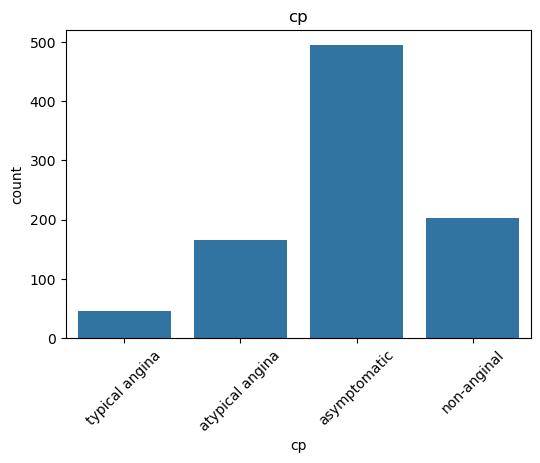

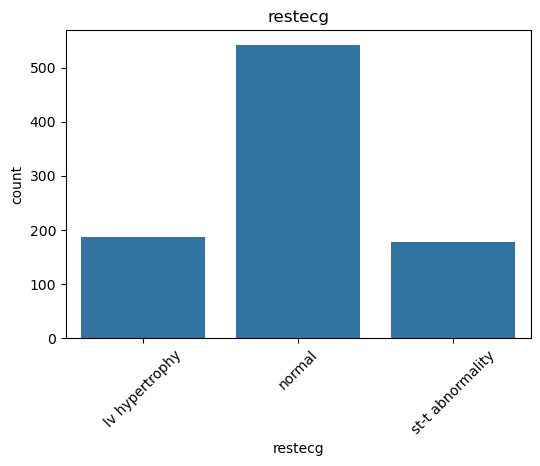

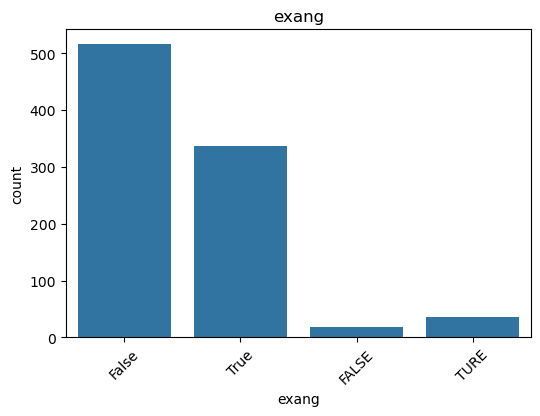

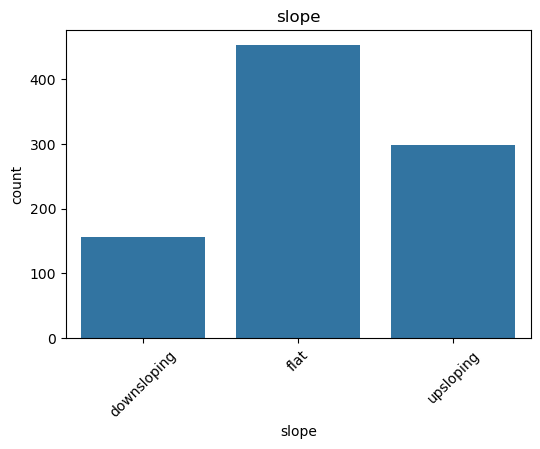

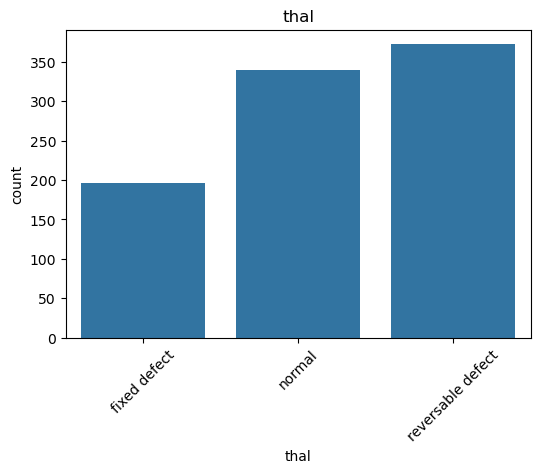

In [240]:
# Count Plot
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.title(col)
    plt.show()

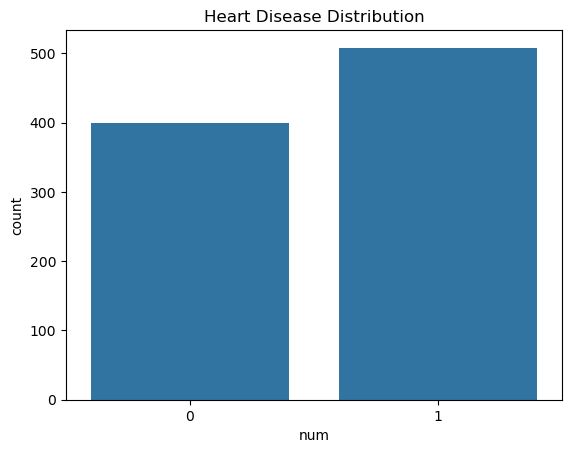

In [241]:
# Target Distribution
sns.countplot(x='num', data=df)
plt.title("Heart Disease Distribution")
plt.show()

# Task 3: Feature Engineering

### Label Encoding

In [242]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
cat_cols = df.select_dtypes(include=['object', 'bool']).columns
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,1,3,145,233,1,0,150,1,2.3,0,0,0
1,41,1,1,135,203,0,1,132,1,0.0,1,0,0
2,57,1,0,140,192,0,1,148,1,0.4,1,0,0
3,52,1,3,118,186,0,0,190,1,0.0,1,0,0
4,57,1,0,110,201,0,1,126,3,1.5,1,0,0


In [243]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 907 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       907 non-null    int64  
 1   sex       907 non-null    int64  
 2   cp        907 non-null    int64  
 3   trestbps  907 non-null    int64  
 4   chol      907 non-null    int64  
 5   fbs       907 non-null    int64  
 6   restecg   907 non-null    int64  
 7   thalch    907 non-null    int64  
 8   exang     907 non-null    int64  
 9   oldpeak   907 non-null    float64
 10  slope     907 non-null    int64  
 11  thal      907 non-null    int64  
 12  num       907 non-null    int64  
dtypes: float64(1), int64(12)
memory usage: 99.2 KB


In [244]:
# Separating features and targets
X = df.drop('num', axis=1)
y = df['num']

#### Train Test Split

In [245]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y) #Using stratify=y is important for multiclass datasets because it preserves the class proportions in both the training and testing sets.

# Task 4. Decision Tree Classification:

In [246]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score,precision_score, recall_score,f1_score,roc_auc_score, roc_curve


In [247]:
#Build The Model
dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    random_state=42
)
dt_model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [248]:
def eval_clf(y,yhat):
    cm = confusion_matrix(y,yhat)
    plt.figure(figsize=(2,2))
    sns.heatmap(cm, cbar=False, annot=True, fmt='d')
    plt.show()
    print(classification_report(y,yhat))

# 6. Model Evaluation and Analysis:

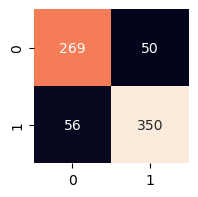

              precision    recall  f1-score   support

           0       0.83      0.84      0.84       319
           1       0.88      0.86      0.87       406

    accuracy                           0.85       725
   macro avg       0.85      0.85      0.85       725
weighted avg       0.85      0.85      0.85       725



In [249]:
#Training Prediction
yhat_train = dt_model.predict(X_train)
eval_clf(y_train,yhat_train)

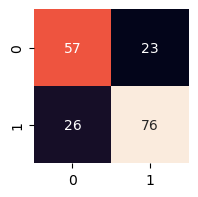

              precision    recall  f1-score   support

           0       0.69      0.71      0.70        80
           1       0.77      0.75      0.76       102

    accuracy                           0.73       182
   macro avg       0.73      0.73      0.73       182
weighted avg       0.73      0.73      0.73       182



In [250]:
#Testing Prediction
yhat_test = dt_model.predict(X_test)
eval_clf(y_test,yhat_test)


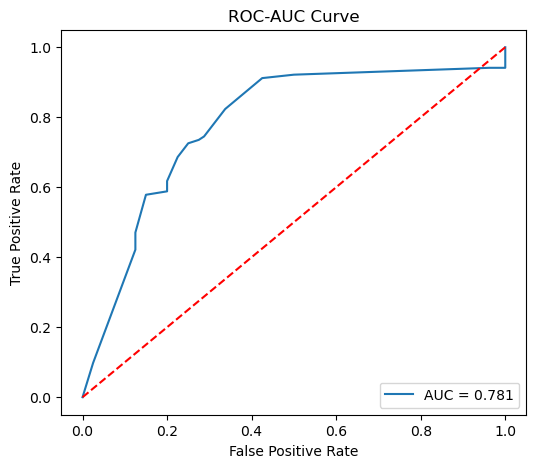

ROC-AUC Score: 0.7808823529411765


In [251]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probability of positive class
y_prob = tree.predict_proba(X_test)[:,1]

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC Score
auc = roc_auc_score(y_test, y_prob)

# Plot
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0,1], [0,1], 'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve')
plt.legend(loc='lower right')
plt.show()

print("ROC-AUC Score:", auc)

In [252]:
from sklearn.model_selection import GridSearchCV

In [253]:
params = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10]
}

In [254]:
grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=params,
    cv=5,
    scoring='accuracy'
)
grid.fit(X_train, y_train)

,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [255]:
print("Best Parameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

Best Parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 5}
Best CV Accuracy: 0.7613793103448276


In [256]:
tree = grid.best_estimator_

yhat_train = tree.predict(X_train)
yhat_test = tree.predict(X_test)

print("Training:", tree.score(X_train, y_train))
print("Testing :", tree.score(X_test, y_test))

Training: 0.8510344827586207
Testing : 0.7307692307692307


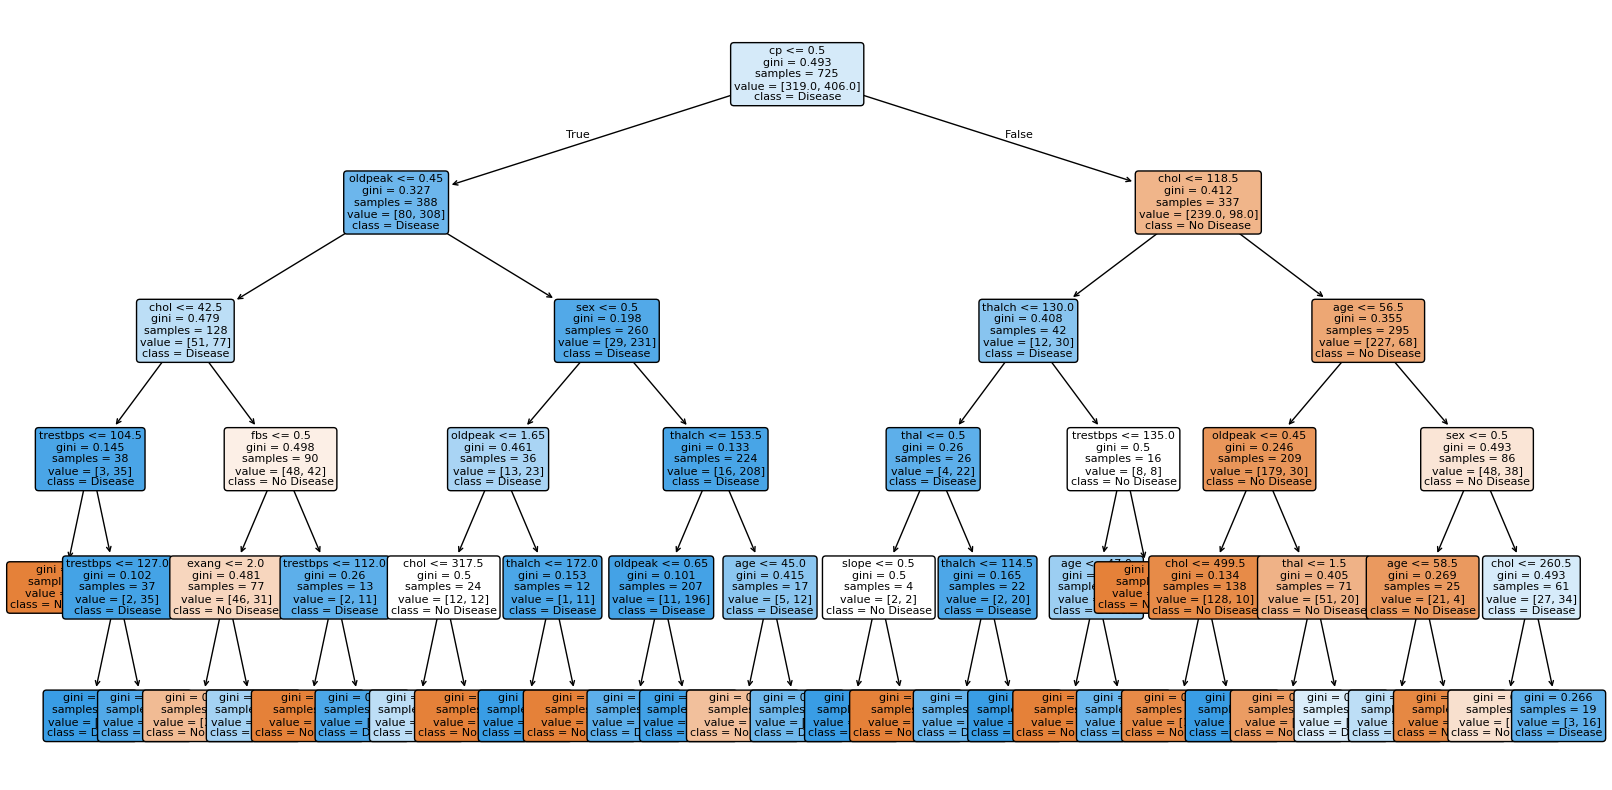

In [257]:
# Decision Tree Visualization
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=['No Disease','Disease'],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()

In [258]:
#Feature importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
2,cp,0.446469
4,chol,0.180266
9,oldpeak,0.105692
0,age,0.080272
1,sex,0.052860
7,thalch,0.031640
3,trestbps,0.030275
11,thal,0.025153
5,fbs,0.021409
8,exang,0.016179


## 1. What are some common hyperparameters of Decision Tree models, and how do they affect the model's performance?
Common hyperparameters include max_depth, min_samples_split, min_samples_leaf, and criterion, which control how the tree is built.
Proper tuning helps prevent overfitting, improves generalisation, and enhances prediction accuracy.

## 2. What is the difference between Label Encoding and One-Hot Encoding?
Label Encoding assigns a unique integer to each category, while One-Hot Encoding creates separate binary columns for each category.
Label Encoding is suitable for ordinal data, whereas One-Hot Encoding is preferred for nominal data to avoid introducing false order.